# Module 5 Lab 3: Textbook Problem 5.5
## Correlations Between Age, Income, and Number of Vehicles

In [1]:
import pandas as pd

custdata = pd.read_csv("custdata.tsv", sep="\t")
custdata[["age", "income", "num.vehicles"]].head()

,age,income,num.vehicles
0,49.0,11300,2.0
1,40.0,0,3.0
2,22.0,4500,3.0
3,22.0,20000,0.0
4,31.0,12000,1.0


### Correlations Before Cleaning

In [2]:
correlation_before = custdata[["age", "income", "num.vehicles"]].corr()
correlation_before


,age,income,num.vehicles
age,1.000000,0.027429,-0.063666
income,0.027429,1.000000,0.139198
num.vehicles,-0.063666,0.139198,1.000000


### Identify Invalid Values


In [3]:
custdata[["age", "income", "num.vehicles"]].describe()

,age,income,num.vehicles
count,1000.000000,1000.000000,944.000000
mean,51.699815,53504.771000,1.916314
std,18.863433,65478.065729,1.101618
min,0.000000,-8700.000000,0.000000
25%,38.000000,14600.000000,1.000000
50%,50.000000,35000.000000,2.000000
75%,64.000000,67000.000000,2.000000
max,146.680197,615000.000000,6.000000


In [4]:
print("Ages of 0 or less:")
print(custdata.loc[custdata["age"] <= 0, "age"].value_counts())

print("\nAges over 100:")
print(custdata.loc[custdata["age"] > 100, "age"].sort_values().to_string(index=False))

print("\nNegative incomes:")
print((custdata["income"] < 0).sum())

print("\nMissing vehicle counts:")
print(custdata["num.vehicles"].isna().sum())

Ages of 0 or less:
age
0.0    3
Name: count, dtype: int64

Ages over 100:
113.337207
123.061023
124.845087
126.737284
130.401605
136.052160
137.700030
146.680197

Negative incomes:
1

Missing vehicle counts:
56


In [5]:
invalid_age = (custdata["age"] <= 0) | (custdata["age"] > 100)
invalid_income = custdata["income"] < 0
missing_vehicles = custdata["num.vehicles"].isna()

invalid_rows = invalid_age | invalid_income | missing_vehicles

print("Invalid ages:", invalid_age.sum())
print("Negative incomes:", invalid_income.sum())
print("Missing vehicle counts:", missing_vehicles.sum())
print("Total unique rows to remove:", invalid_rows.sum())
print("Rows remaining:", (~invalid_rows).sum())

Invalid ages: 11
Negative incomes: 1
Missing vehicle counts: 56
Total unique rows to remove: 68
Rows remaining: 932


### Clean the Data

In [6]:
custdata_clean = custdata.loc[~invalid_rows].copy()

print("Original rows:", len(custdata))
print("Rows removed:", len(custdata) - len(custdata_clean))
print("Rows remaining:", len(custdata_clean))

Original rows: 1000
Rows removed: 68
Rows remaining: 932


### Correlations After Cleaning

In [7]:
correlation_after = custdata_clean[["age", "income", "num.vehicles"]].corr()
correlation_after

,age,income,num.vehicles
age,1.000000,-0.002644,-0.066295
income,-0.002644,1.000000,0.137859
num.vehicles,-0.066295,0.137859,1.000000


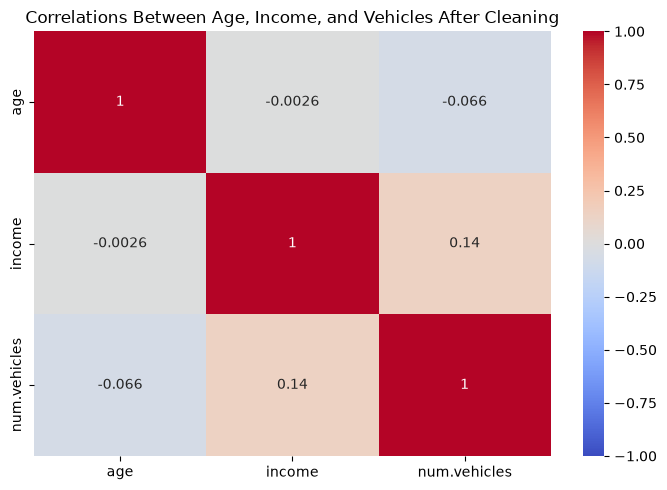

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.heatmap(correlation_after, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlations Between Age, Income, and Vehicles After Cleaning")
plt.tight_layout()
plt.show()

### Results

Before cleaning (1,000 records): Age–income: 0.0274; age–vehicles: −0.0637; income–vehicles: 0.1392.
Cleaning: I removed 68 records: 11 invalid ages (0 or over 100), 1 negative income, and 56 missing vehicle counts.
After cleaning (932 records): Age–income: −0.0026 (almost no correlation); age–vehicles: −0.0663 (very weak negative); income–vehicles: 0.1379 (weak positive). Cleaning changed the age–income correlation the most, but the overall findings remained similar.